In [1]:
import sys
import os
sys.path.append(os.path.abspath("../../../src"))

In [2]:
import pandas as pd
df = pd.read_csv("../../../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
from utils.preprocess import create_features
df = create_features(df)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,_log_amount,Hour_from_start_mod24,is_night_proxy,is_business_hours_proxy
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0,1,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0,1,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0,1,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0,1,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0,1,0


In [4]:
#Tách Feature và Label
X = df.drop(["Class", "Time"], axis=1).columns.to_list()
y = "Class"

In [5]:
from utils import *
X_train, y_train, X_val, y_val, X_test, y_test = split_data(df, X, y)

X_train: (181584, 33) y_train: (181584,)
X_val: (45396, 33) y_val: (45396,)
X_test: (56746, 33) y_test: (56746,)
Fraud rate in train: 0.001910961318177813
Fraud rate in test: 0.0013040566735981391


In [6]:
#Dùng Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [7]:
pipe.named_steps["model"].n_iter_

array([35], dtype=int32)

In [8]:
#Predict xác suất
y_val_prob = pipe.predict_proba(X_val)[:, 1]
y_test_prob = pipe.predict_proba(X_test)[:, 1]
print(y_val_prob)
print(y_test_prob)

[0.01317983 0.10692782 0.05534639 ... 0.00027914 0.02447189 0.03172686]
[0.020414   0.01766961 0.01418569 ... 0.02209851 0.0777073  0.14370899]


In [9]:
from utils import *
b = evaluate(y_test, y_test_prob, thr=0.969)
print(b['tp'])
print(b['fp'])
print(b['fn'])
print(b['tn'])
print(pd.Series(y_test).value_counts())

62
116
12
56556
Class
0    56672
1       74
Name: count, dtype: int64


In [10]:
from utils import *
result_lr_val = log_eval(y_val, y_val_prob)
result_lr_test = log_eval(y_test, y_test_prob)

print("Logistic Regression - Validation Set:")
print(result_lr_val)

print("Logistic Regression - Test Set:")
print(result_lr_test)

Logistic Regression - Validation Set:
{'threshold': 0.907, 'Cost': 2400.0, 'ROC_AUC': 0.9729554584441671, 'PR_AUC': 0.7749693650102897, 'debiased_ece': np.float64(0.07986530135307693), 'adaptive_ece': np.float64(0.07986858946650069), 'Brier': 0.027838020549325607}
Logistic Regression - Test Set:
{'threshold': 0.969, 'Cost': 2980.0, 'ROC_AUC': 0.9856811171349215, 'PR_AUC': 0.7414676125025982, 'debiased_ece': np.float64(0.09330061149602878), 'adaptive_ece': np.float64(0.0933209710974977), 'Brier': 0.033658975150694964}


In [11]:
"""tính ngưỡng threshold để đạt được chi phí thấp nhất."""
thr_thapI, cost_thapI = thr_min_cost(y_test, y_test_prob)
print(thr_thapI, cost_thapI)

0.969 2980.0


In [12]:
"""tính ngưỡng threshold để đạt được độ chính xác (precision) metric oke nhất"""
res = thr_for_precision(y_test, y_test_prob, target_prec=0.969)
print(res)

{'threshold': 0.9999997674287394, 'precision': 0.9772727272727273, 'recall': 0.581081081081081}


In [13]:
"""tính ngưỡng threshold để đạt được độ chính xác (precision) 90%"""
res = thr_for_precision(y_test, y_test_prob, target_prec=0.9)
print(res)

{'threshold': 0.9999914763396318, 'precision': 0.9090909090909091, 'recall': 0.6756756756756757}


In [14]:
#Tuning threshold
#threshold = 0.5  #  không phù hợp với imbalanced
import numpy as np

threshold = 0.969
y_val_pred = (y_val_prob > threshold).astype(int)
print(y_val_pred)

[0 0 0 ... 0 0 0]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45344
           1       0.35      0.79      0.49        52

    accuracy                           1.00     45396
   macro avg       0.68      0.89      0.74     45396
weighted avg       1.00      1.00      1.00     45396



In [16]:
"""quét qua các ngưỡng threshold thử nhiều giá trị threshold khác nhau, 
    tính các metric tương ứng để xem threshold nào tốt nhất."""
df_sweep = sweep_thresholds(y_test, y_test_prob)
print(df_sweep.head())
thr_target = 0.967
row = df_sweep.iloc[(df_sweep['threshold'] - thr_target).abs().idxmin()]

print(row)

   threshold  precision  recall        f1  tp    tn     fp  fn      cost
0      0.000   0.001304     1.0  0.002605  74     0  56672   0  283360.0
1      0.001   0.001362     1.0  0.002721  74  2424  54248   0  271240.0
2      0.002   0.001396     1.0  0.002787  74  3721  52951   0  264755.0
3      0.003   0.001422     1.0  0.002841  74  4721  51951   0  259755.0
4      0.004   0.001450     1.0  0.002896  74  5718  50954   0  254770.0
threshold        0.967000
precision        0.340659
recall           0.837838
f1               0.484375
tp              62.000000
tn           56552.000000
fp             120.000000
fn              12.000000
cost          3000.000000
Name: 967, dtype: float64


## Plot

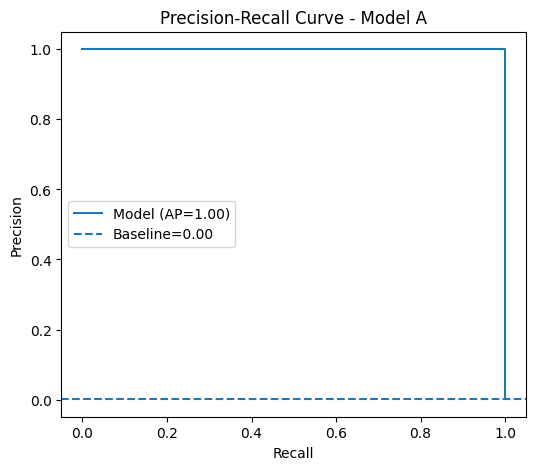

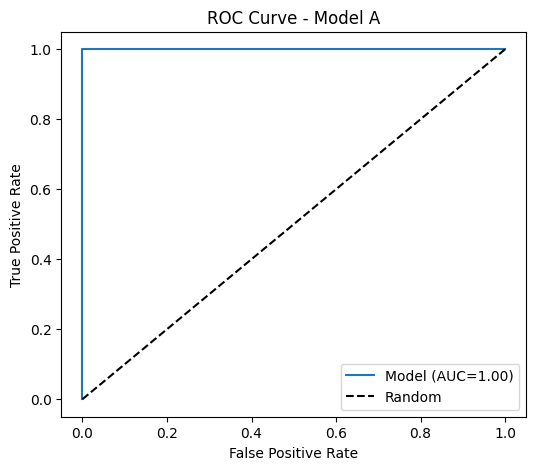

In [17]:
# Đánh giá tổng thể
plot_pr_roc(y_test, y_test, "Model A")

## Sampling comparison

In [18]:
# Sampling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Pipeline (PHẢI dùng của imblearn, không phải sklearn)
from imblearn.pipeline import Pipeline

# Model + preprocess
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import average_precision_score, roc_auc_score, recall_score

# Utils
import numpy as np
import pandas as pd
samplers = {
    "None": None,
    "Under": RandomUnderSampler(random_state=SEED),
    "SMOTE": SMOTE(random_state=SEED),
    "SMOTE+Tomek": SMOTETomek(random_state=SEED),
}

In [19]:
from imblearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, recall_score

results = []

for name, sampler in samplers.items():
    steps = []
    
    if sampler is not None:
        steps.append(("sampler", sampler))
    
    steps.extend([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ])
    
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    
    # Predict
    y_val_score = pipe.predict_proba(X_val)[:,1]
    y_test_score = pipe.predict_proba(X_test)[:,1]
    
    # AUPRC
    auprc_val = average_precision_score(y_val, y_val_score)
    auprc_test = average_precision_score(y_test, y_test_score)
    
    # ROC
    roc_test = roc_auc_score(y_test, y_test_score)
    
    # Recall với threshold = 0.5 (tạm)
    y_test_pred = (y_test_score >= 0.5).astype(int)
    recall_test = recall_score(y_test, y_test_pred)
    
    results.append({
        "method": name,
        "AUPRC_val": auprc_val,
        "AUPRC_test": auprc_test,
        "ROC_test": roc_test,
        "Recall_test": recall_test
    })

pd.DataFrame(results)

,method,AUPRC_val,AUPRC_test,ROC_test,Recall_test
0,None,0.670584,0.707237,0.974340,0.513514
1,Under,0.332044,0.494683,0.986949,0.918919
2,SMOTE,0.770859,0.770847,0.965275,0.891892
3,SMOTE+Tomek,0.770859,0.770847,0.965275,0.891892
